用torch解决分类问题

# 加载样本,熟悉样本

In [21]:
# 导入FashionMNIST数据集
from torchvision.datasets import FashionMNIST

train_data=FashionMNIST(root='./data',train=True,download=True)
test_data=FashionMNIST(root='./data',train=False,download=True)
print(train_data[0])
print(len(train_data))
print(len(test_data))

(<PIL.Image.Image image mode=L size=28x28 at 0x161D5E190>, 9)
60000
10000


In [22]:
print(train_data.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


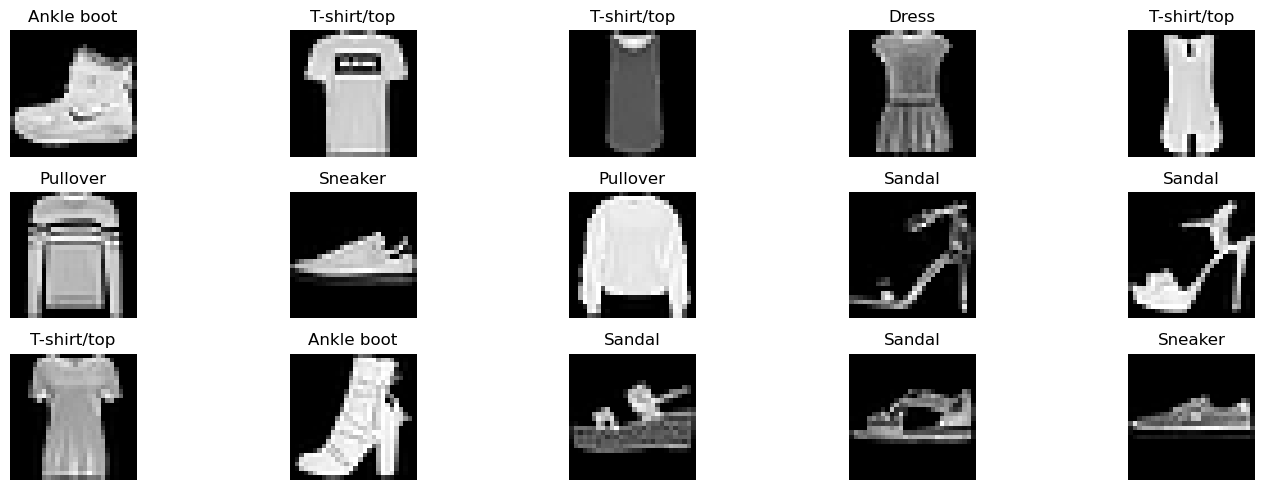

In [23]:
import matplotlib.pyplot as plt

class_name=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']    

plt.figure(figsize=(15,5))
for i in range(15):
    image,label=train_data[i]
    plt.subplot(3,5,i+1)
    plt.imshow(image,cmap='gray')
    plt.title(class_name[label])
    plt.axis('off')
    
plt.tight_layout()
plt.show()    

0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 13 73 0 0 1 4 0 0 0 0 1 1 0
0 0 0 0 0 0 0 0 0 0 0 0 3 0 36 136 127 62 54 0 0 0 1 3 4 0 0 3
0 0 0 0 0 0 0 0 0 0 0 0 6 0 102 204 176 134 144 123 23 0 0 0 0 12 10 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 155 236 207 178 107 156 161 109 64 23 77 130 72 15
0 0 0 0 0 0 0 0 0 0 0 1 0 69 207 223 218 216 216 163 127 121 122 146 141 88 172 66
0 0 0 0 0 0 0 0 0 1 1 1 0 200 232 232 233 229 223 223 215 213 164 127 123 196 229 0
0 0 0 0 0 0 0 0 0 0 0 0 0 183 225 216 223 228 235 227 224 222 224 221 223 245 173 0
0 0 0 0 0 0 0 0 0 0 0 0 0 193 228 218 213 198 180 212 210 211 213 223 220 243 202 0
0 0 0 0 0 0 0 0 0 1 3 0 12 219 220 212 218 192 169 227 208 218 224 212 226 197 209 52
0 0 0 0 0 0 0 0 0 0 6 0 99 244 222 220 218 203 198 221 215 213 222 220 245 119 167 56
0 0 0 0 0 0 0 0 0 4 0 0 55 236 228 230 228 240 232 213

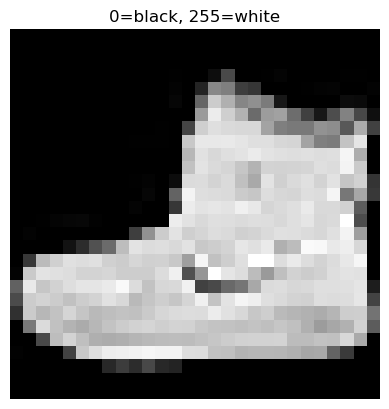

In [24]:
#  images 是一个形状为 (N, 28, 28) 的 numpy 数组，存储了 N 张 28x28 的图片
images ,label=train_data[0]
import numpy as np
from PIL import Image
#images是PIL Image对象，需要转换为numpy数组
images_array=np.array(images)
for row in images_array:              # 遍历每一行
    print(' '.join(str(pixel) for pixel in row))
    
# 显示图片，观察0和255对应的颜色
import matplotlib.pyplot as plt

# 将numpy数组转换为PIL Image并显示
img = Image.fromarray(images_array.astype(np.uint8))
plt.imshow(img, cmap='gray')
plt.title('0=black, 255=white')
plt.axis('off')
plt.show()

    

# 变为tensor,Dataloader分批

In [25]:
from sympy import im
import torch
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import FashionMNIST

# 定义transform,将PIL Image转换为Tensor,并归一化到[0, 1]
transform = transforms.ToTensor()

# 加载FashionMNIST数据集
train_dataset_tensor = FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset_tensor = FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)
# 打印第一个样本的标签
print("Train first label:", train_dataset_tensor.targets[0].item())
print("Test first label:", test_dataset_tensor.targets[0].item())

# 打印第一个样本的图像张量形状
print("Train tensor shape:", train_dataset_tensor.data[0][0].shape)
print("Test tensor shape:", test_dataset_tensor.data[0][0].shape)



# 使用 DataLoader 分批
batch_size = 64  # 定义 DataLoader

train_loader = DataLoader(train_dataset_tensor, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset_tensor, batch_size=batch_size, shuffle=False)





Train first label: 9
Test first label: 9
Train tensor shape: torch.Size([28])
Test tensor shape: torch.Size([28])


In [26]:
# 遍历train_loader打印一个batch后break
for images, labels in train_loader:
    
    print("Images Batch shape:", images.shape)#[64, 1, 28, 28]
    '''64: 批量大小, 1: 通道数, 28: 高度, 28: 宽度'''
    print("Labels Batch shape:", labels.shape)
    print("First image tensor:", images[0])
    print("First label:", labels[0])
    break

Images Batch shape: torch.Size([64, 1, 28, 28])
Labels Batch shape: torch.Size([64])
First image tensor: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.1333, 0.1098, 0.0000, 0.0000, 0.2588,
          0.1098, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.1569, 0.6588, 0.9098, 0.8784, 0.8549, 0.8706,
          0.5490, 0.0784, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.1490, 0.2824, 0.4863, 0.2902, 0.7686, 0.7765, 0.7608, 0.7529,
          0.1098, 0.4471, 0.2510, 0.1255, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1490,
          0.5412, 0.2980, 

## 构建神经网络模型
结构：输入784 → 隐藏层300 → 隐藏层100 → 输出10（FashionMNIST）\n
- 激活函数：ReLU\n
- 损失函数：CrossEntropyLoss（直接接收logits）\n
- 优化器：Adam

In [27]:
import torch  # 导入 PyTorch 主库
import torch.nn as nn  # 导入 PyTorch 的神经网络模块，用于构建网络层


# 定义一个继承自 nn.Module 的神经网络类
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()  # 调用父类 nn.Module 的构造函数，完成必要的初始化
        # 将输入的多维张量展平为一维向量，例如将 28×28 的图像展平为 784 维向量
        self.flatten = nn.Flatten()

        # 使用 nn.Sequential 顺序容器定义前馈网络结构
        # 漏斗结构：展平->全连接层1(784->300)->ReLU1->全连接层2(300->100)->ReLU2->输出层(100->10)
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 300),  # 全连接层：输入维度 28×28=784，输出维度 300
            nn.ReLU(),  # ReLU 激活函数，引入非线性(增加非线性拟合能力)
            nn.Linear(300, 100),  # 全连接层：输入维度 300，输出维度 100
            nn.ReLU(),  # ReLU 激活函数
            nn.Linear(100, 10),  # 全连接层：输入维度 100，输出维度 10（对应 10 类分类）
        )

    # 定义前向传播逻辑：输入 x 经过展平后，通过顺序网络得到输出
    def forward(self, x):# 前向传播函数，定义了输入 x 如何通过网络层进行前向计算
        x = self.flatten(x)  # 展平输入张量，将多维图像数据转换为一维向量
        x = self.fc1(x)  # 通过全连接层1，将784维特征映射到300维
        # print("After flatten:", x.shape)  # 打印展平后的张量形状，便于调试
        x = self.relu1(x)  # 通过ReLU1激活函数，引入非线性，增强模型表达能力
        # print(''''''''''''sdfasdsafasfdafdasfssdafda"After relu1:", x.shape)    # 打印经过第一个激活函数后的张量形状
        x = self.fc2(x)  # 通过全连接层2，将300维特征映射到100维
        # print("After fc2:", x.shape)    # 打印经过第二个全连接层后的张量形状
        x = self.relu2(x)  # 通过ReLU2激活函数，再次引入非线性
        # print("After relu2:", x.shape)  # 打印经过第二个激活函数后的张量形状
        x = self.outp(x)  # 通过输出层，将100维特征映射到10维，对应10个类别
        # print("After outp:", x.shape)   # 打印最终输出张量形状，应为[batch_size, 10]
        return x  # 返回前向传播结果，用于后续计算损失和预测


# 根据当前环境选择计算设备：优先使用 GPU（cuda），否则使用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 实例化神经网络，并将其参数与缓存移动到所选设备（GPU/CPU）
model = NeuralNetwork().to(device)
# 定义交叉熵损失函数，用于多分类任务
criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数，内部有做softmax
# 定义 Adam 优化器，学习率设为 0.001，用于更新模型参数
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# 打印模型结构，方便查看网络层次与参数量
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)


In [28]:
import torch

#随机生成一个输入
random_input = torch.randn(1, 784)

#实例化模型
model=NeuralNetwork()

#向前计算
output=model(random_input)

print("Model output:", output)


AttributeError: 'NeuralNetwork' object has no attribute 'fc1'

Epoch 1/5 - loss: 2.3020 - test_acc: 0.1456
Epoch 2/5 - loss: 2.3020 - test_acc: 0.1456
Epoch 3/5 - loss: 2.3020 - test_acc: 0.1456
Epoch 4/5 - loss: 2.3020 - test_acc: 0.1456
Epoch 5/5 - loss: 2.3020 - test_acc: 0.1456


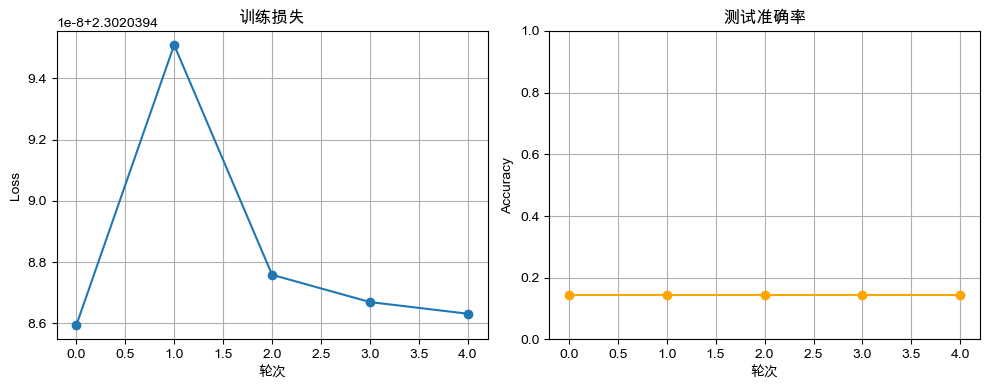

              precision    recall  f1-score   support

           0     0.7315    0.4440    0.5526      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.3359    0.0430    0.0762      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.0000    0.0000    0.0000      1000
           8     0.1052    0.9690    0.1898      1000
           9     0.0000    0.0000    0.0000      1000

    accuracy                         0.1456     10000
   macro avg     0.1173    0.1456    0.0819     10000
weighted avg     0.1173    0.1456    0.0819     10000



/Applications/Anaconda/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Applications/Anaconda/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Applications/Anaconda/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

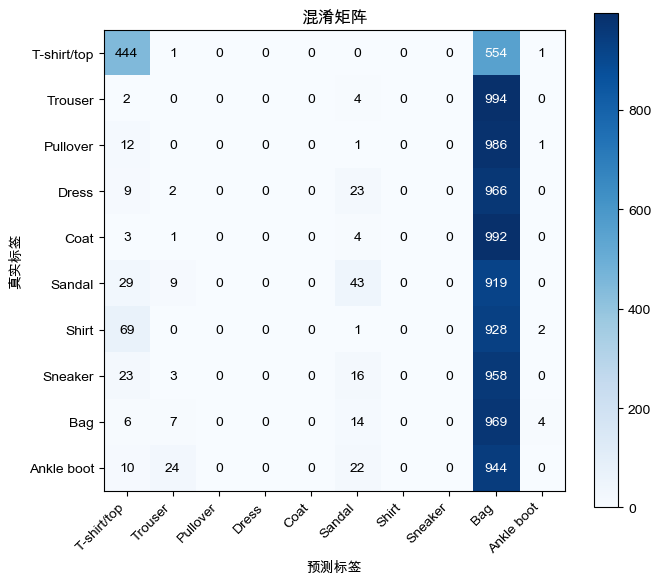

In [32]:
from train_and_estimate import Trainer
import torch
 
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

num_epochs=10

trainer=Trainer(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs
)
trainer.train()
trainer.plot()



KeyboardInterrupt: 